In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/violence_detection_project"
DATASET_ROOT = f"{PROJECT_ROOT}/dataset/kaggle/input/rwf2000/RWF-2000"

TRAIN_DIR = f"{DATASET_ROOT}/train"
VAL_DIR = f"{DATASET_ROOT}/val"
TEST_DIR = f"{DATASET_ROOT}/test"

In [ ]:
import os
def build_video_list(root_dir):
  video_list=[]
  label_map = {"NonFight":0,"Fight":1}
  for label_name,label in label_map.items():
    class_dir = os.path.join(root_dir,label_name)
    for video in os.listdir(class_dir):
      if video.endswith(".avi"):
        video_list.append(
            (os.path.join(class_dir,video),label)
        )
  return video_list

train_videos = build_video_list(TRAIN_DIR)
val_videos = build_video_list(VAL_DIR)
test_videos = build_video_list(TEST_DIR)

len(train_videos),len(val_videos),len(test_videos)


(1600, 400, 20)

In [ ]:
import cv2

def get_total_frames(video_path):
  cap=cv2.VideoCapture(video_path)
  total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  cap.release
  return total

video_path,label=train_videos[0]
get_total_frames(video_path)


150

In [ ]:
import numpy as np

def get_tsn_indices(total_frames, num_segments, mode):
    segment_length = total_frames // num_segments
    indices = []

    for i in range(num_segments):
        start = i * segment_length

        if mode == "train":
            offset = np.random.randint(0, segment_length)
        else:  # validation
            offset = segment_length // 2

        indices.append(start + offset)

    return indices

 This code defines a function called get_tsn_indices. This function is designed to select specific frame indices from a video, which is a common technique in Temporal Segment Networks (TSN) for action recognition.

Here's how it works:

Input Parameters: It takes total_frames (the total number of frames in the
video), num_segments (how many segments you want to divide the video into), and mode (either 'train' or 'validation').

Segment Length Calculation: It first calculates segment_length by dividing the total_frames by num_segments. This means each segment will have an equal number of frames.

Index Selection Loop: It then iterates num_segments times, representing each segment.

Offset for Training vs. Validation: Inside the loop, for each segment:
If mode is 'train', it adds a random offset within that segment to introduce variability (data augmentation).
If mode is 'validation' (or any other mode), it picks the middle frame of that segment by setting the offset to segment_length // 2 to ensure consistent sampling.



Return Value: Finally, it returns a list of indices, which are the selected frame numbers for processing.

In [ ]:
def extract_tsn_frames(video_path,frame_indices):
  cap = cv2.VideoCapture(video_path)
  frames=[]

  for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES,idx)
    ret,frame=cap.read()
    if not ret:
      raise RuntimeError(f"Failed to read frame {idx}")
    frames.append(frame)
  cap.release()
  return frames

The code defines a function called extract_tsn_frames. This function takes a video_path and a list of frame_indices as input. It uses OpenCV (cv2) to open the video, then iterates through the provided frame_indices. For each index, it seeks to that specific frame in the video, reads it, and appends it to a list. Finally, it releases the video capture object and returns the list of extracted frames. This function is essential for sampling specific frames from a video, which is a common step in video processing for tasks like action recognition.

In [ ]:
video_path,label=train_videos[0]
total_frames=get_total_frames(video_path)

frame_indices=get_tsn_indices(total_frames,7,"train")
frames=extract_tsn_frames(video_path,frame_indices)

len(frames),frames[0].shape,label

(7, (240, 320, 3), 0)

We have to convert the TSN frames into PyTorch tensors.
A tensor is a general name for numbers arranged in multiple dimensions.

Here , TSN frames format is (H,W,3) H->height, W->width, 3->no.of channels(RGB)

PyTorch uses (C,W,H) format.

What we are converting

Each frame currently is:

(H, W, 3)   ← NumPy array


We want each frame to become:

(3, H, W)   ← PyTorch tensor


And then stack K frames into:

(K, 3, H, W)


That single tensor represents one video.

In [ ]:
import torch
import numpy as np

# ImageNet normalization values (standard)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def frame_to_tensor(frame):

    frame = cv2.resize(frame, (224, 224))
    # BGR → RGB
    frame = frame[:, :, ::-1]

    # uint8 → float32 and scale to [0, 1]
    frame = frame.astype(np.float32) / 255.0

    # NumPy → Torch
    frame = torch.from_numpy(frame)

    # (H, W, C) → (C, H, W)
    frame = frame.permute(2, 0, 1)

    # Normalize
    frame = (frame - IMAGENET_MEAN) / IMAGENET_STD

    return frame


ImageNet Normalization Values: IMAGENET_MEAN and IMAGENET_STD are predefined mean and standard deviation values used for normalizing images. These specific values are commonly used when working with models pre-trained on the ImageNet dataset, ensuring consistency in data preprocessing.

this function prepares raw image frames by converting their color space, normalizing pixel values, and reordering dimensions to match the input requirements of typical PyTorch convolutional neural networks.

In [ ]:
tsn_frames = [frame_to_tensor(f) for f in frames]

len(tsn_frames), tsn_frames[0].shape

(7, torch.Size([3, 224, 224]))

In [ ]:
tsn_tensor = torch.stack(tsn_frames)
tsn_tensor.shape

torch.Size([7, 3, 224, 224])

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 2

backbone = models.resnet18(pretrained=True)
backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
backbone.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Setting up pre-trained ResNet18 model.
num_classes = 2 : defines the number of classes for the classification problem( Fight or Non Fight)


In [ ]:
tsn_tensor = tsn_tensor.unsqueeze(0)
tsn_tensor.shape

torch.Size([1, 7, 3, 224, 224])

In [ ]:
with torch.no_grad():
  B,K,C,H,W = tsn_tensor.shape

  images = tsn_tensor.view(B*K,C,H,W)

  logits = backbone(images)
  logits = logits.view(B,K,num_classes)
  video_logits = logits.mean(dim=1)

video_logits

tensor([[-0.4411, -1.0754]])

Above TSN implementation is done with one video.



In [ ]:
from torch.utils.data import Dataset

class TSNDataset(Dataset):
    def __init__(self, video_list, num_segments=5, mode="train"):
        self.video_list = video_list
        self.num_segments = num_segments
        self.mode = mode

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_path, label = self.video_list[idx]
        total_frames = get_total_frames(video_path)
        frame_indices = get_tsn_indices(total_frames,self.num_segments,self.mode)

        frames = extract_tsn_frames(video_path, frame_indices)
        tsn_frames = [frame_to_tensor(f) for f in frames]
        tsn_tensor = torch.stack(tsn_frames)


        return tsn_tensor, label


In [ ]:
train_dataset = TSNDataset(train_videos, num_segments=8, mode="train")
val_dataset = TSNDataset(val_videos, num_segments=8, mode="validation")
test_dataset = TSNDataset(test_videos, num_segments=8, mode="test")
len(train_dataset)

1600

This code defines a custom dataset class called TSNDataset, which is a common practice in PyTorch for handling data. It inherits from torch.utils.data.Dataset, making it compatible with PyTorch's data loading utilities. The __init__ method initializes the dataset with a list of videos, the desired number of segments per video (currently set to 5), and a mode (e.g., 'train'). The __len__ method simply returns the total number of videos in the dataset. The __getitem__ method is crucial; it defines how a single item (a video and its label) is retrieved given an index. Currently, it's a placeholder that just returns the video path and label. Finally, the code instantiates TSNDataset with your train_videos and then demonstrates accessing the first item in the dataset.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size = 4,
    shuffle=True,
    num_workers = 2, #parallel loading
    pin_memory = True #
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 4,
    shuffle = False,
    num_workers = 2,
    pin_memory= True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 4,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
)


In [ ]:
#Test

batch = next(iter(train_loader))
videos,labels=batch
videos.shape, labels.shape


(torch.Size([4, 8, 3, 224, 224]), torch.Size([4]))

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class TSNModel(nn.Module):
  def __init__(self,num_classes=2,backbone_name = "resnet18", pretrained = True):
    super().__init__()

    if backbone_name == "resnet18":
      backbone = models.resnet18(pretrained=pretrained)
      in_features = backbone.fc.in_features
      backbone.fc = nn.Linear(in_features,num_classes)
    else:
      raise ValueError("Unsupported Backbone")

    self.backbone = backbone
    self.num_classes = num_classes

  def forward(self,x):
    """  x: Tensor of shape [B, K, 3, H, W]
        returns: Tensor of shape [B, num_classes]
        """
    B,K,C,H,W = x.shape
    x = x.view(B*K,C,H,W)

    logits = self.backbone(x)

    logits=logits.view(B,K,self.num_classes)

    video_logits = logits.mean(dim=1)

    return video_logits

In [ ]:
model = TSNModel(num_classes=2)
model.eval()

with torch.no_grad():
  x=tsn_tensor
  out=model(x)

out,out.shape

ValueError: not enough values to unpack (expected 5, got 4)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSNModel(num_classes=2,pretrained=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_one_epoch(model,loader,optimizer,criterion,device):
  model.train()
  total_loss = 0.0
  correct = 0
  total = 0


  for videos,labels in loader:
    videos = videos.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(videos)
    loss=criterion(outputs,labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item() * labels.size(0)
    preds = outputs.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

  avg_loss = total_loss / total
  accuracy = correct / total

  return avg_loss, accuracy


In [ ]:
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


In [ ]:
train_loss, train_acc = train_one_epoch(
    model, train_loader, optimizer, criterion, device
)

val_loss, val_acc = validate(
    model, val_loader, criterion, device
)

train_loss, train_acc, val_loss, val_acc


(0.6208876041136682, 0.68375, 0.5629718864895403, 0.79)

In [ ]:
torch.save(model.state_dict(), f"{PROJECT_ROOT}/tsn_epoch_1.pth")

In [ ]:
best_val_acc = 0

num_epochs = 3
for epoch in range(2,num_epochs+1):
  train_loss, train_acc = train_one_epoch(
    model, train_loader, optimizer, criterion, device
)

  val_loss, val_acc = validate(
    model, val_loader, criterion, device
)

  print(f"Epoch {epoch} |"
        f"Train Loss: {train_loss:.4f} |"
      f"Train Acc: {train_acc:.4f} |"
      f"Val Loss: {val_loss:.4f} |"
      f"Val Acc: {val_acc:.4f}")

  torch.save(model.state_dict(),f"{PROJECT_ROOT}/tsn_epoch_{epoch}")
  if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            f"{PROJECT_ROOT}/tsn_best.pth"
        )

Epoch 2 |Train Loss: 0.6335 |Train Acc: 0.6769 |Val Loss: 0.5172 |Val Acc: 0.7600
Epoch 3 |Train Loss: 0.5181 |Train Acc: 0.7581 |Val Loss: 0.6481 |Val Acc: 0.7125


Epoch 1 |Train Loss:0.6208 |Train Acc: 0.6838 |Val Loss: 0.5630 |Val Acc: 0.79

Epoch 2 |Train Loss: 0.6335 |Train Acc: 0.6769 |Val Loss: 0.5172 |Val Acc: 0.7600

Epoch 3 |Train Loss: 0.5181 |Train Acc: 0.7581 |Val Loss: 0.6481 |Val Acc: 0.7125

In [ ]:
import shutil

shutil.copy(
    f"{PROJECT_ROOT}/tsn_epoch_1.pth",
    f"{PROJECT_ROOT}/tsn_best.pth"
)


'/content/drive/MyDrive/violence_detection_project/tsn_best.pth'

In [ ]:
train_loss, train_acc = train_one_epoch(
    model, train_loader, optimizer, criterion, device
)

val_loss, val_acc = validate(
    model, val_loader, criterion, device
)

train_loss, train_acc, val_loss, val_acc


(0.6359958618879318, 0.666875, 0.6832078454643488, 0.6075)

In [ ]:
train_loss, train_acc = train_one_epoch(
    model, train_loader, optimizer, criterion, device
)

val_loss, val_acc = validate(
    model, val_loader, criterion, device
)

train_loss, train_acc, val_loss, val_acc


(0.6212896202970296, 0.68125, 0.5436681500077247, 0.7025)

### Class Diagram Description

Here's a breakdown of the key classes and their relationships in this project:

#### 1. `TSNDataset`
- **Type**: Custom PyTorch `torch.utils.data.Dataset`
- **Description**: Handles the loading and preprocessing of video data for the Temporal Segment Network (TSN) model.
- **Attributes**:
  - `video_list`: A list of tuples, where each tuple contains `(video_path, label)`.
  - `num_segments`: Integer, the number of segments to divide each video into for TSN sampling.
  - `mode`: String, indicates whether it's 'train' or 'validation' to determine frame sampling strategy.
- **Methods**:
  - `__init__(self, video_list, num_segments=5, mode="train")`: Initializes the dataset.
  - `__len__(self)`: Returns the total number of videos in the dataset.
  - `__getitem__(self, idx)`: Retrieves a processed video tensor and its label for a given index.
- **Dependencies**: Internally uses the utility functions `get_total_frames`, `get_tsn_indices`, `extract_tsn_frames`, and `frame_to_tensor`.

#### 2. `TSNModel`
- **Type**: Custom PyTorch `torch.nn.Module`
- **Description**: Defines the neural network architecture for video classification, integrating a pre-trained image classification backbone with TSN-specific logic.
- **Attributes**:
  - `backbone`: An instance of a `torchvision` model (e.g., `resnet18`), adapted for the specific number of classes.
  - `num_classes`: Integer, the number of output classes for the classification task.
- **Methods**:
  - `__init__(self, num_classes=2, backbone_name="resnet18", pretrained=True)`: Initializes the model, sets up the backbone, and modifies its final layer.
  - `forward(self, x)`: Defines the forward pass of the model. Takes a batch of video segments `[B, K, C, H, W]` and outputs `[B, num_classes]`.
- **Relationships**: *Composition* with a `torchvision.models` backbone (e.g., `resnet18`).

#### 3. Utility Functions (Conceptual)
These are not classes but are essential functions used by `TSNDataset` and other parts of the pipeline:
- `build_video_list(root_dir)`: Scans a directory and creates a list of video paths and their corresponding labels.
- `get_total_frames(video_path)`: Uses OpenCV to get the total number of frames in a given video.
- `get_tsn_indices(total_frames, num_segments, mode)`: Calculates the frame indices to be sampled from a video based on the TSN strategy.
- `extract_tsn_frames(video_path, frame_indices)`: Extracts specific frames from a video using OpenCV.
- `frame_to_tensor(frame)`: Transforms a raw image frame (NumPy array) into a normalized PyTorch tensor, including resizing, color space conversion, and normalization.

#### 4. Training/Validation Functions (Conceptual)
These functions encapsulate the training and evaluation logic:
- `train_one_epoch(model, loader, optimizer, criterion, device)`: Performs a single training epoch, including forward pass, loss calculation, backward pass, and optimizer step.
- `validate(model, loader, criterion, device)`: Evaluates the model on a validation set without gradient computation.

#### Relationships Overview:
- `TSNDataset` **uses** (depends on) `get_total_frames`, `get_tsn_indices`, `extract_tsn_frames`, `frame_to_tensor`.
- `TSNModel` **has-a** `backbone` (e.g., `ResNet18`).
- The main execution script (not a class itself) **creates** instances of `TSNDataset`, `DataLoader`, `TSNModel`, `nn.CrossEntropyLoss`, and `optim.Adam`.
- The main execution script **calls** `train_one_epoch` and `validate`, passing instances of `TSNModel`, `DataLoader`, `optimizer`, `criterion`, and `device`.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSNModel(num_classes = 2,pretrained=False)
model.load_state_dict(
    torch.load(f"{PROJECT_ROOT}/tsn_best.pth",map_location=device)
)
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


TSNModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [ ]:
def evaluate(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, all_preds, all_labels

In [ ]:
val_acc, preds, labels = evaluate(model, val_loader, device)

print("Validation Accuracy:", val_acc)

KeyboardInterrupt: 

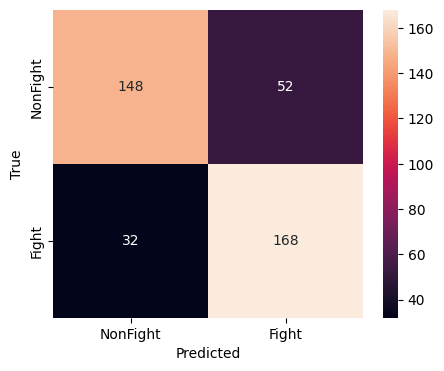

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["NonFight","Fight"],
            yticklabels=["NonFight","Fight"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Prediction: Fight 
Ground truth: Fight
Video path: /content/drive/MyDrive/violence_detection_project/dataset/kaggle/input/rwf2000/RWF-2000/val/Fight/48J5lk4QcpE_2.avi


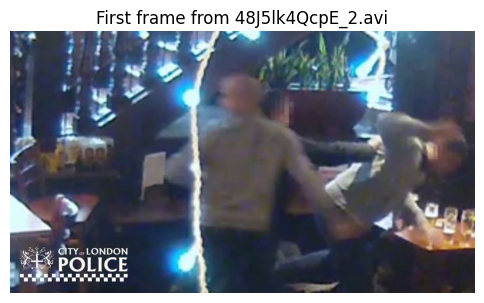

In [ ]:
import IPython.display as ipd
import cv2
import matplotlib.pyplot as plt

video_idx = 324
video_info, label = val_dataset[video_idx]
video_path, _ = val_videos[video_idx]

video = video_info.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(video)
    pred = output.argmax(dim=1).item()

if pred == 0:
  pred_label = "Non Fight"
else:
  pred_label = "Fight"

if label == 0:
  true_label = "Non Fight"
else:
  true_label = "Fight"

print("Prediction:", pred_label, "\nGround truth:", true_label)
print(f"Video path: {video_path}")


# Extract and display a frame from the video
cap = cv2.VideoCapture(video_path)
if cap.isOpened():
    ret, frame = cap.read()
    if ret:
        # OpenCV reads in BGR, matplotlib expects RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 4))
        plt.imshow(frame_rgb)
        plt.title(f"First frame from {video_path.split('/')[-1]}")
        plt.axis('off')
        plt.show()
    else:
        print("Could not read the first frame.")
else:
    print("Could not open the video file.")
cap.release()

In [ ]:
val_acc, preds, labels = evaluate(model, test_loader, device)
print("Test Accuracy:", val_acc)

Test Accuracy: 0.65


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSNModel(num_classes=2, pretrained=False)

model.load_state_dict(
    torch.load(f"{PROJECT_ROOT}/tsn_best.pth", map_location=device)
)

model = model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(3):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)
    print("Val Loss:", val_loss)
    print("Val Acc:", val_acc)
    torch.save(model.state_dict(),f"{PROJECT_ROOT}/tsn2_epoch_{epoch+1}")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7803556027a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Epoch 1
Train Loss: 0.49976507511921225
Train Acc: 0.77625
Val Loss: 0.6359716883487999
Val Acc: 0.71
Epoch 2
Train Loss: 0.43456755854189394
Train Acc: 0.81
Val Loss: 0.5275240637175739
Val Acc: 0.775
Epoch 3
Train Loss: 0.37692063926719127
Train Acc: 0.835625
Val Loss: 0.5702012599259615
Val Acc: 0.725
